In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

global_wheat_detection_path = kagglehub.competition_download('global-wheat-detection')
indroneelroy_yolomodel_path = kagglehub.dataset_download('indroneelroy/yolomodel')
indroneelroy_yolo_pytorch_default_1_path = kagglehub.model_download('indroneelroy/yolo/PyTorch/default/1')

print('Data source import complete.')


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Create a new Kaggle notebook
# Settings → Accelerator → GPU T4 x2 (or P100)
# Settings → Internet → ON (to download packages)

# Verify GPU
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Count: {torch.cuda.device_count()}")

GPU Available: True
GPU Name: Tesla T4
GPU Count: 2


In [ ]:
# Install latest Ultralytics (includes YOLOv11)
!pip install ultralytics -q
!pip install pandas numpy matplotlib seaborn opencv-python albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00a 0:00:01


Total training images: 3373
Total bounding boxes: 147793

Dataset shape: (147793, 5)

First few rows:
    image_id  width  height                         bbox   source
0  b6ab77fd7   1024    1024   [834.0, 222.0, 56.0, 36.0]  usask_1
1  b6ab77fd7   1024    1024  [226.0, 548.0, 130.0, 58.0]  usask_1
2  b6ab77fd7   1024    1024  [377.0, 504.0, 74.0, 160.0]  usask_1
3  b6ab77fd7   1024    1024  [834.0, 95.0, 109.0, 107.0]  usask_1
4  b6ab77fd7   1024    1024  [26.0, 144.0, 124.0, 117.0]  usask_1

📊 Dataset Statistics:
Images per source:
source
ethz_1       51489
arvalis_1    45716
rres_1       20236
arvalis_3    16665
usask_1       5807
arvalis_2     4179
inrae_1       3701
Name: count, dtype: int64

Bboxes per image:
count    3373.000000
mean       43.816484
std        20.374820
min         1.000000
25%        28.000000
50%        43.000000
75%        59.000000
max       116.000000
dtype: float64


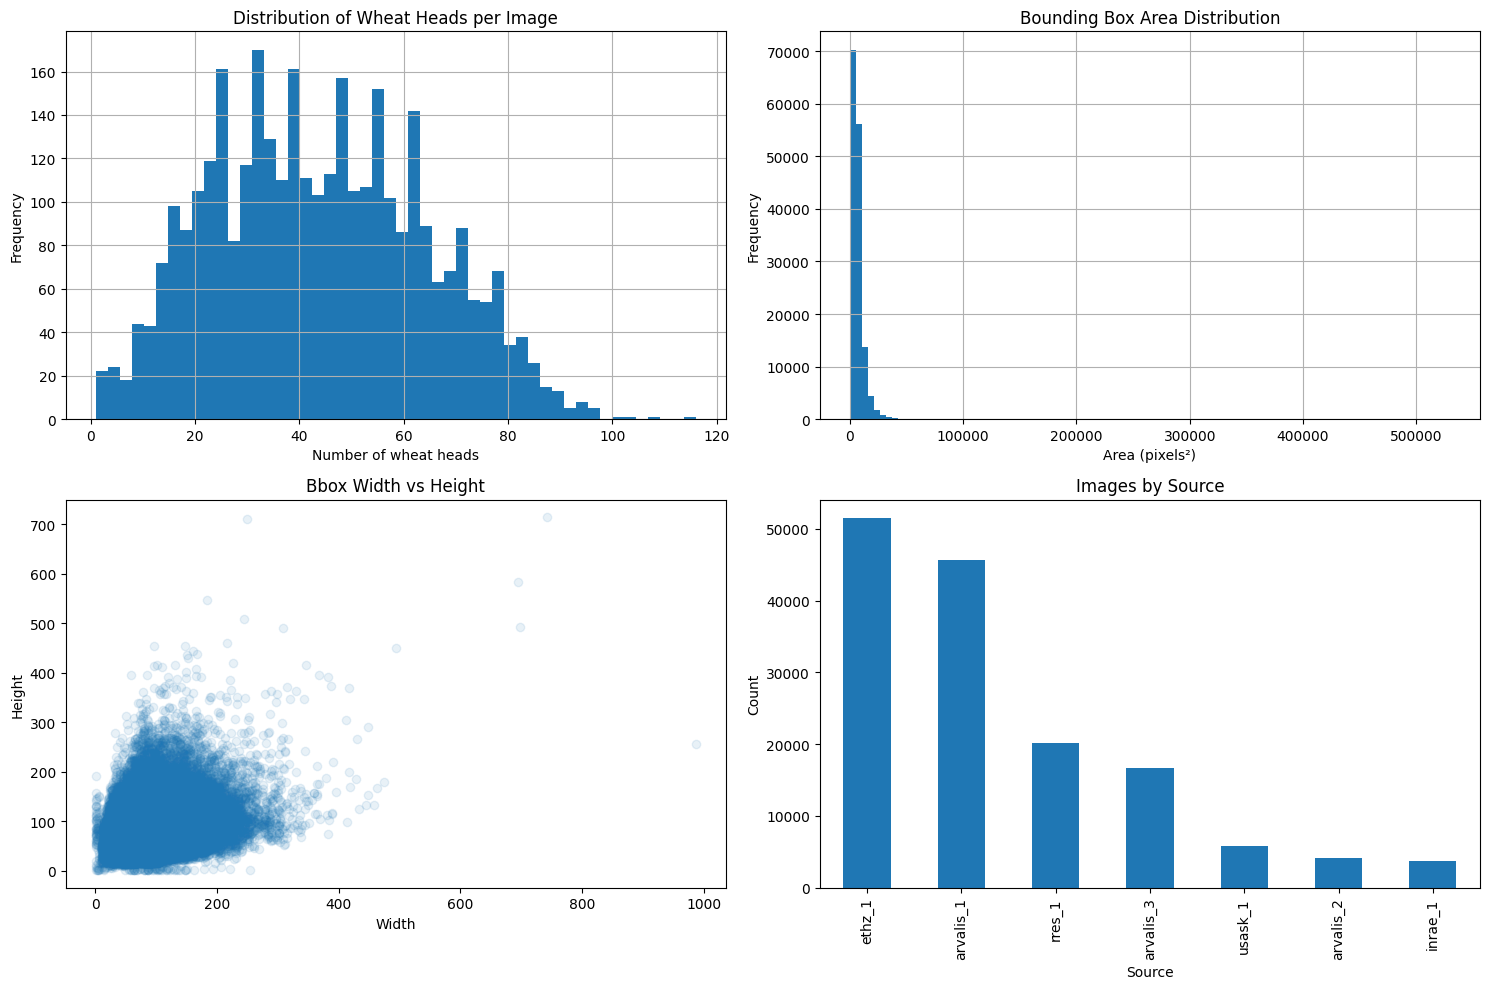

In [ ]:
# Load training annotations
train_df = pd.read_csv('/kaggle/input/global-wheat-detection/train.csv')

print(f"Total training images: {train_df['image_id'].nunique()}")
print(f"Total bounding boxes: {len(train_df)}")
print(f"\nDataset shape: {train_df.shape}")
print(f"\nFirst few rows:")
print(train_df.head())

# Parse bbox column: [xmin, ymin, width, height]
train_df[['xmin', 'ymin', 'width', 'height']] = train_df['bbox'].str.strip('[]').str.split(',', expand=True).astype(float)

# Calculate bbox center and area
train_df['x_center'] = train_df['xmin'] + train_df['width'] / 2
train_df['y_center'] = train_df['ymin'] + train_df['height'] / 2
train_df['area'] = train_df['width'] * train_df['height']

# Analyze distribution
print(f"\n📊 Dataset Statistics:")
print(f"Images per source:")
print(train_df['source'].value_counts())
print(f"\nBboxes per image:")
print(train_df.groupby('image_id').size().describe())

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Wheat heads per image
train_df.groupby('image_id').size().hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Distribution of Wheat Heads per Image')
axes[0,0].set_xlabel('Number of wheat heads')
axes[0,0].set_ylabel('Frequency')

# 2. Bbox area distribution
train_df['area'].hist(bins=100, ax=axes[0,1])
axes[0,1].set_title('Bounding Box Area Distribution')
axes[0,1].set_xlabel('Area (pixels²)')
axes[0,1].set_ylabel('Frequency')

# 3. Bbox width/height distribution
axes[1,0].scatter(train_df['width'], train_df['height'], alpha=0.1)
axes[1,0].set_title('Bbox Width vs Height')
axes[1,0].set_xlabel('Width')
axes[1,0].set_ylabel('Height')

# 4. Source distribution
train_df['source'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Images by Source')
axes[1,1].set_xlabel('Source')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
train_df.head()

,image_id,width,height,bbox,source,xmin,ymin,x_center,y_center,area
0,b6ab77fd7,56.0,36.0,"[834.0, 222.0, 56.0, 36.0]",usask_1,834.0,222.0,862.0,240.0,2016.0
1,b6ab77fd7,130.0,58.0,"[226.0, 548.0, 130.0, 58.0]",usask_1,226.0,548.0,291.0,577.0,7540.0
2,b6ab77fd7,74.0,160.0,"[377.0, 504.0, 74.0, 160.0]",usask_1,377.0,504.0,414.0,584.0,11840.0
3,b6ab77fd7,109.0,107.0,"[834.0, 95.0, 109.0, 107.0]",usask_1,834.0,95.0,888.5,148.5,11663.0
4,b6ab77fd7,124.0,117.0,"[26.0, 144.0, 124.0, 117.0]",usask_1,26.0,144.0,88.0,202.5,14508.0


## Visualize Sample Images

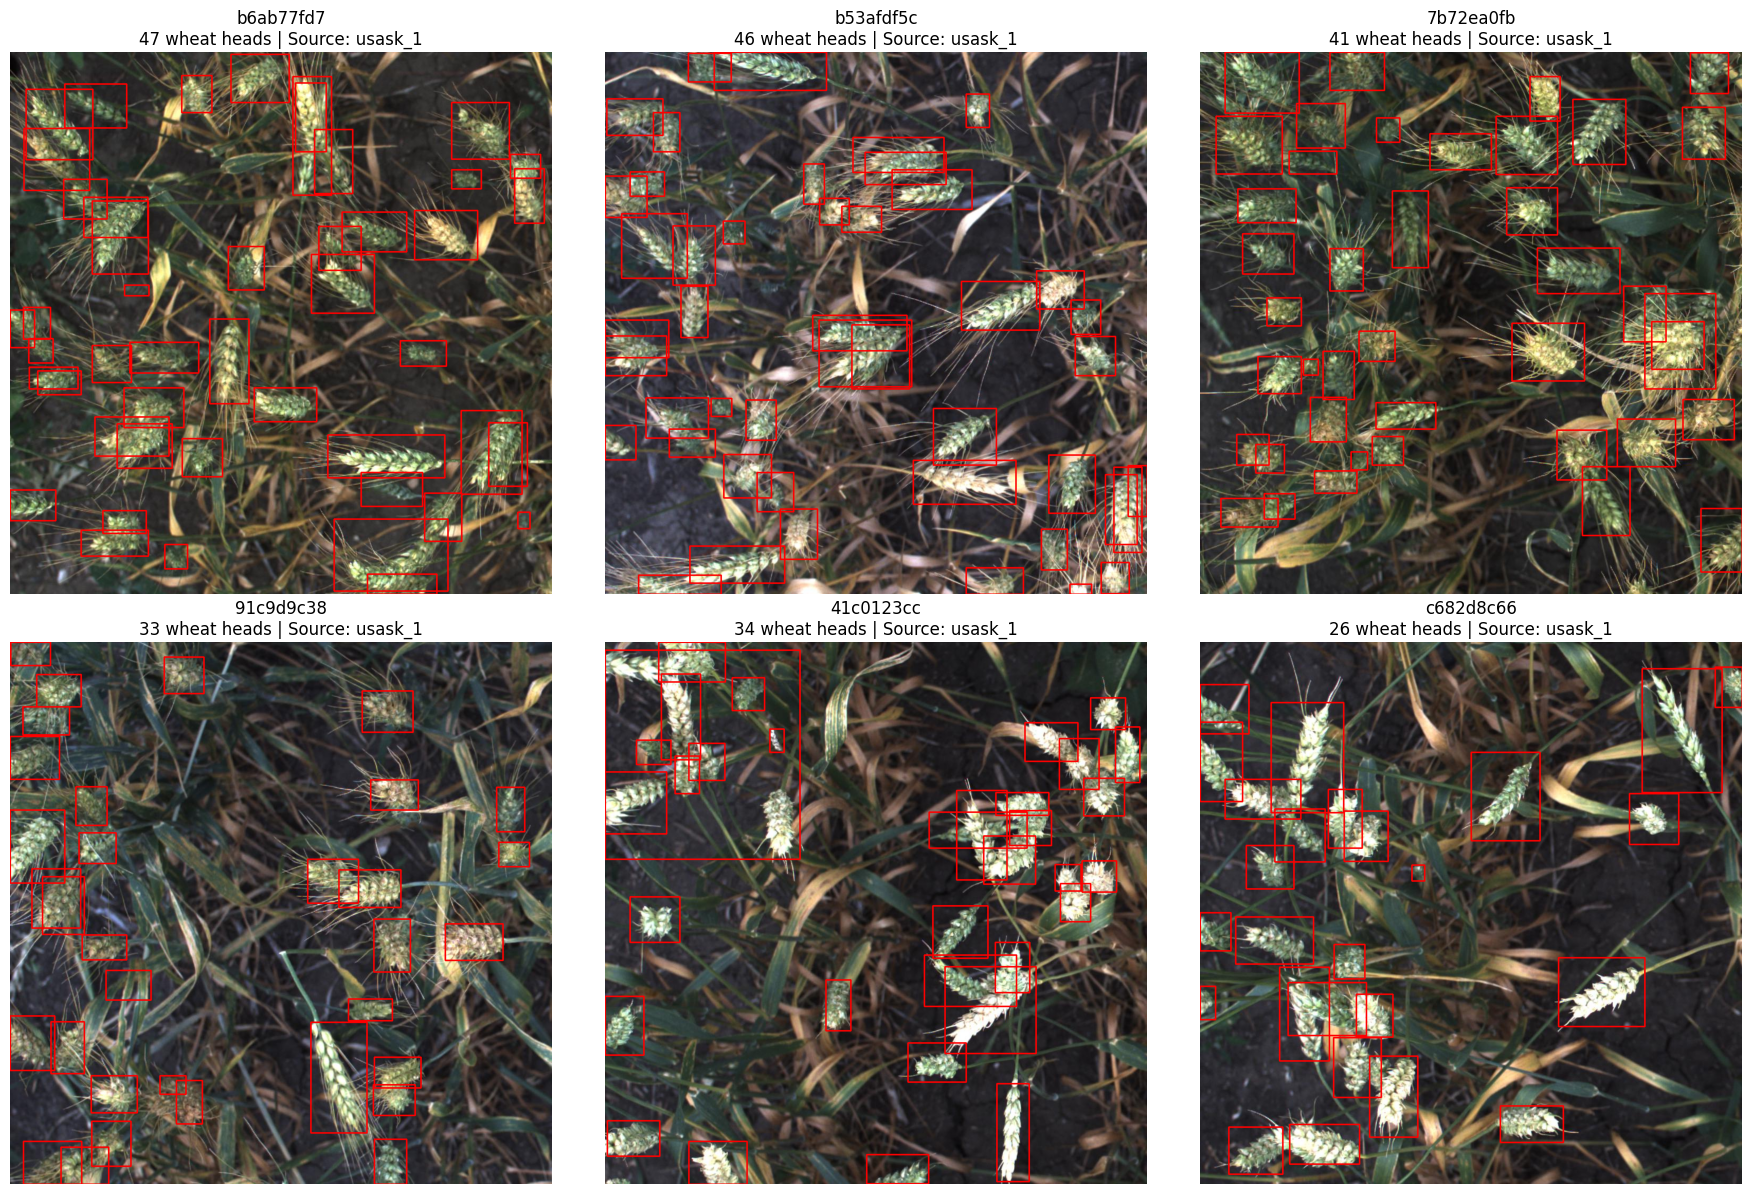


✅ Sample images saved!


In [ ]:
def visualize_wheat_images(df, img_dir, num_samples=6):
    """Visualize sample images with bounding boxes"""

    # Get random sample images
    sample_images = df['image_id'].unique()[:num_samples]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, img_id in enumerate(sample_images):
        # Load image
        img_path = f"{img_dir}/{img_id}.jpg"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get bboxes for this image
        img_bboxes = df[df['image_id'] == img_id]

        # Draw bboxes
        for _, row in img_bboxes.iterrows():
            x, y, w, h = int(row['xmin']), int(row['ymin']), int(row['width']), int(row['height'])
            cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_id}\n{len(img_bboxes)} wheat heads | Source: {img_bboxes.iloc[0]['source']}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize
train_img_dir = '/kaggle/input/global-wheat-detection/train'
visualize_wheat_images(train_df, train_img_dir, num_samples=6)

print(f"\n✅ Sample images saved!")

##  Convert to YOLO Format

In [ ]:
from sklearn.model_selection import train_test_split
import shutil
import os

# Create directory structure
base_dir = '/kaggle/working/wheat_yolo'
os.makedirs(f"{base_dir}/images/train", exist_ok=True)
os.makedirs(f"{base_dir}/images/val", exist_ok=True)
os.makedirs(f"{base_dir}/labels/train", exist_ok=True)
os.makedirs(f"{base_dir}/labels/val", exist_ok=True)

# Split data (80% train, 20% val)
unique_images = train_df['image_id'].unique()
train_images, val_images = train_test_split(unique_images, test_size=0.2, random_state=42)

print(f"Train images: {len(train_images)}")
print(f"Val images: {len(val_images)}")

def convert_to_yolo_format(df, image_id, img_width=1024, img_height=1024):
    """Convert bbox to YOLO format: class x_center y_center width height (normalized)"""

    img_data = df[df['image_id'] == image_id]
    yolo_labels = []

    for _, row in img_data.iterrows():
        # Calculate YOLO format
        x_center = (row['xmin'] + row['width'] / 2) / img_width
        y_center = (row['ymin'] + row['height'] / 2) / img_height
        width = row['width'] / img_width
        height = row['height'] / img_height

        # Class 0 for wheat head
        yolo_labels.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return yolo_labels

# Process training images
print("\n📁 Processing training images...")
for img_id in tqdm(train_images):
    # Copy image
    src_img = f"/kaggle/input/global-wheat-detection/train/{img_id}.jpg"
    dst_img = f"{base_dir}/images/train/{img_id}.jpg"
    shutil.copy(src_img, dst_img)

    # Create label file
    labels = convert_to_yolo_format(train_df, img_id)
    label_file = f"{base_dir}/labels/train/{img_id}.txt"
    with open(label_file, 'w') as f:
        f.write('\n'.join(labels))

# Process validation images
print("\n📁 Processing validation images...")
for img_id in tqdm(val_images):
    # Copy image
    src_img = f"/kaggle/input/global-wheat-detection/train/{img_id}.jpg"
    dst_img = f"{base_dir}/images/val/{img_id}.jpg"
    shutil.copy(src_img, dst_img)

    # Create label file
    labels = convert_to_yolo_format(train_df, img_id)
    label_file = f"{base_dir}/labels/val/{img_id}.txt"
    with open(label_file, 'w') as f:
        f.write('\n'.join(labels))

print("\n✅ Dataset conversion complete!")

# Verify
print(f"\nTrain images: {len(os.listdir(f'{base_dir}/images/train'))}")
print(f"Train labels: {len(os.listdir(f'{base_dir}/labels/train'))}")
print(f"Val images: {len(os.listdir(f'{base_dir}/images/val'))}")
print(f"Val labels: {len(os.listdir(f'{base_dir}/labels/val'))}")

Train images: 2698
Val images: 675

📁 Processing training images...


100%|██████████| 2698/2698 [01:03<00:00, 42.75it/s]



📁 Processing validation images...


100%|██████████| 675/675 [00:16<00:00, 41.76it/s]


✅ Dataset conversion complete!

Train images: 2698
Train labels: 2698
Val images: 675
Val labels: 675


## Create data.yaml for YOLO training

In [ ]:
# Create data.yaml for YOLO training
yaml_content = f"""
# Global Wheat Head Detection Dataset

# Paths
path: {base_dir}
train: images/train
val: images/val

# Classes
nc: 1  # number of classes
names: ['wheat']  # class names
"""

yaml_path = f"{base_dir}/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ YAML config created at:", yaml_path)
print("\nYAML Contents:")
print(yaml_content)

✅ YAML config created at: /kaggle/working/wheat_yolo/data.yaml

YAML Contents:

# Global Wheat Head Detection Dataset

# Paths
path: /kaggle/working/wheat_yolo
train: images/train
val: images/val

# Classes
nc: 1  # number of classes
names: ['wheat']  # class names



# Train YOLOv11 Model

This cell trains a YOLOv11 model on the wheat detection dataset. The training process includes:

## Model Configuration
- **Model**: YOLOv11-Medium (`yolo11m.pt`) - optimal balance between speed and accuracy
- **Alternative models**: Nano (fastest), Small, Large, XLarge (most accurate)

## Training Parameters
- **Epochs**: 50 (increase to 150-200 for production models)
- **Image size**: 640×640 pixels (increase to 800 or 1024 for better accuracy)
- **Batch size**: 8 (adjust based on GPU memory - use 4 for less memory, 16 for more)
- **Early stopping**: Patience of 20 epochs to prevent overfitting

## Data Augmentation
The model uses extensive augmentation to improve generalization:
- **Color**: HSV adjustments for lighting variations
- **Geometric**: Rotation (±10°), translation, scaling, flipping
- **Advanced**: Mosaic (combines 4 images) and mixup (blends images)

## Optimization Settings
- **Optimizer**: AdamW with learning rate schedule (0.01 → 0.001)
- **Loss weights**: Balanced for bounding box, classification, and distribution focal loss
- **Warmup**: 3 epochs to stabilize early training

## Output
- Models saved every 10 epochs in `wheat_detection/yolo11m_run1/`
- Training plots and metrics generated automatically
- GPU time tracking to monitor Kaggle usage (30 hours/week limit)



In [ ]:
from ultralytics import YOLO
import time

# Track GPU time
start_time = time.time()

# Load pretrained YOLOv11 model
# Options: yolo11n.pt (nano), yolo11s.pt (small), yolo11m.pt (medium),
#          yolo11l.pt (large), yolo11x.pt (xlarge)

model = YOLO("yolo11m.pt")  # Medium model - good balance

# Train the model
results = model.train(
    data=yaml_path,
    epochs=50,              # Increase to 150-200 for better results
    imgsz=640,               # Image size (can try 800, 1024 for better accuracy)
    batch=8,                 # Adjust based on GPU memory (4-16)
    device=0,                # GPU device
    workers=4,               # Data loading workers
    project='wheat_detection',
    name='yolo11m_run1',

    # Optimization settings
    patience=20,             # Early stopping patience
    save=True,
    save_period=10,          # Save checkpoint every 10 epochs
    cache=False,             # Don't cache (saves memory)

    # Data augmentation
    augment=True,
    hsv_h=0.015,             # HSV-Hue augmentation
    hsv_s=0.7,               # HSV-Saturation
    hsv_v=0.4,               # HSV-Value
    degrees=10.0,            # Rotation
    translate=0.1,           # Translation
    scale=0.5,               # Scale
    shear=0.0,               # Shear
    perspective=0.0,         # Perspective
    flipud=0.0,              # Flip up-down
    fliplr=0.5,              # Flip left-right
    mosaic=1.0,              # Mosaic augmentation
    mixup=0.1,               # Mixup augmentation
    copy_paste=0.0,          # Copy-paste augmentation

    # Advanced settings
    optimizer='AdamW',       # Optimizer (SGD, Adam, AdamW)
    lr0=0.01,                # Initial learning rate
    lrf=0.01,                # Final learning rate fraction
    momentum=0.937,          # Momentum
    weight_decay=0.0005,     # Weight decay
    warmup_epochs=3.0,       # Warmup epochs
    warmup_momentum=0.8,     # Warmup momentum
    box=7.5,                 # Box loss gain
    cls=0.5,                 # Class loss gain
    dfl=1.5,                 # DFL loss gain

    # Validation settings
    val=True,
    plots=True,              # Save training plots
    verbose=True,
)

# Calculate time spent
elapsed_time = (time.time() - start_time) / 3600
print(f"\n⏱️  Training completed in {elapsed_time:.2f} hours")
print(f"📊 GPU hours used: {elapsed_time:.2f} / 30")

# Save training results
print("\n✅ Model saved at:", model.ckpt_path)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/wheat_yolo/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, 

##  Evaluate Model


image 1/1 /kaggle/input/global-wheat-detection/test/2fd875eaa.jpg: 640x640 29 wheats, 36.8ms
Speed: 4.4ms preprocess, 36.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/wheat_test
1 label saved to /kaggle/working/test_results/wheat_test/labels

📊 Detection Results:
Number of wheat heads detected: 29

Detections:
  1. Confidence: 0.815 | Box: [0.0, 905.0, 109.5, 997.0]
  2. Confidence: 0.797 | Box: [0.8, 0.0, 118.0, 78.1]
  3. Confidence: 0.793 | Box: [387.5, 789.0, 473.2, 887.4]
  4. Confidence: 0.785 | Box: [100.5, 571.1, 252.9, 670.9]
  5. Confidence: 0.784 | Box: [884.4, 43.6, 1000.4, 144.6]
  6. Confidence: 0.779 | Box: [422.3, 58.1, 539.0, 147.5]
  7. Confidence: 0.776 | Box: [938.4, 641.6, 1024.0, 751.3]
  8. Confidence: 0.774 | Box: [118.3, 839.6, 207.7, 916.7]
  9. Confidence: 0.762 | Box: [900.9, 877.9, 986.0, 982.0]
  10. Confidence: 0.761 | Box: [463.0, 347.1, 593.0, 453.3]
  11. Confidence: 0.759 | Box: [22

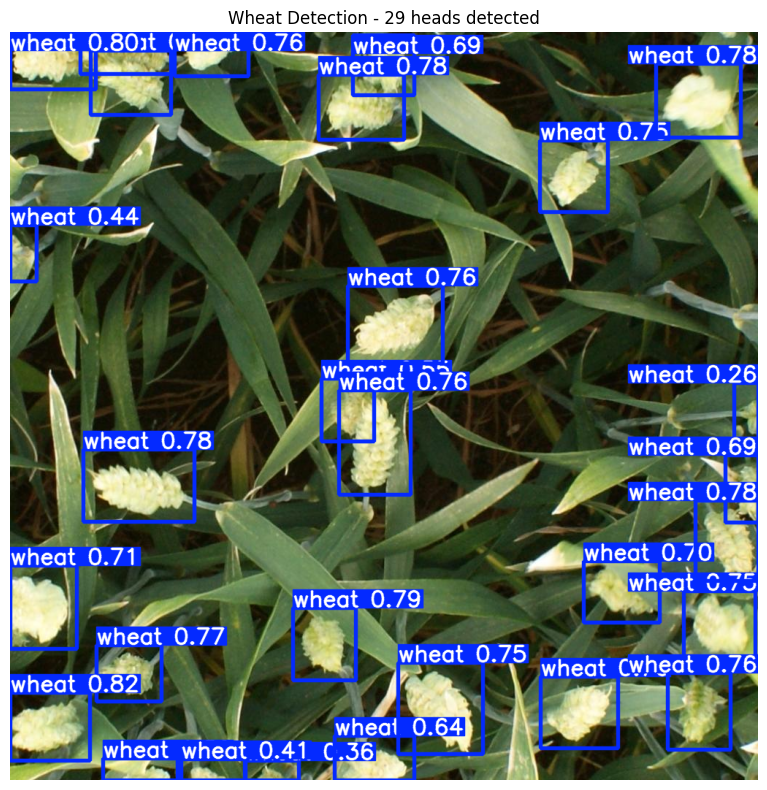


✅ Results saved to: test_results/wheat_test/
📸 Visualization saved to: wheat_detection_result.png


In [ ]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Load your trained model
model_path = 'wheat_detection/yolo11m_run1/weights/best.pt'  # Use best weights
model = YOLO(model_path)

# Path to your test image
image_path = '/kaggle/input/global-wheat-detection/test/2fd875eaa.jpg'  # Replace with your image path

# Run inference
results = model.predict(
    source=image_path,
    conf=0.25,           # Confidence threshold (adjust 0.1-0.5)
    iou=0.45,            # NMS IoU threshold
    show=False,          # Don't show in window
    save=True,           # Save results
    save_txt=True,       # Save detection coordinates
    save_conf=True,      # Save confidence scores
    project='test_results',
    name='wheat_test',
)

# Get the first result
result = results[0]

# Print detection statistics
print(f"\n📊 Detection Results:")
print(f"Number of wheat heads detected: {len(result.boxes)}")
print(f"\nDetections:")
for i, box in enumerate(result.boxes):
    conf = box.conf[0].item()
    cls = int(box.cls[0].item())
    xyxy = box.xyxy[0].tolist()
    print(f"  {i+1}. Confidence: {conf:.3f} | Box: [{xyxy[0]:.1f}, {xyxy[1]:.1f}, {xyxy[2]:.1f}, {xyxy[3]:.1f}]")

# Display the result with matplotlib
img_with_boxes = result.plot()  # Get image with bounding boxes
img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Wheat Detection - {len(result.boxes)} heads detected')
plt.tight_layout()
plt.savefig('wheat_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Results saved to: test_results/wheat_test/")
print(f"📸 Visualization saved to: wheat_detection_result.png")

In [ ]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/yolo/pytorch/default/1/bestyolo_wheat.pt")

In [ ]:
results = model.predict(
    source="/kaggle/input/global-wheat-detection/test/2fd875eaa.jpg",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True
)


image 1/1 /kaggle/input/global-wheat-detection/test/2fd875eaa.jpg: 640x640 29 wheats, 36.8ms
Speed: 3.1ms preprocess, 36.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict3



0: 640x640 21 wheats, 36.9ms
Speed: 3.4ms preprocess, 36.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

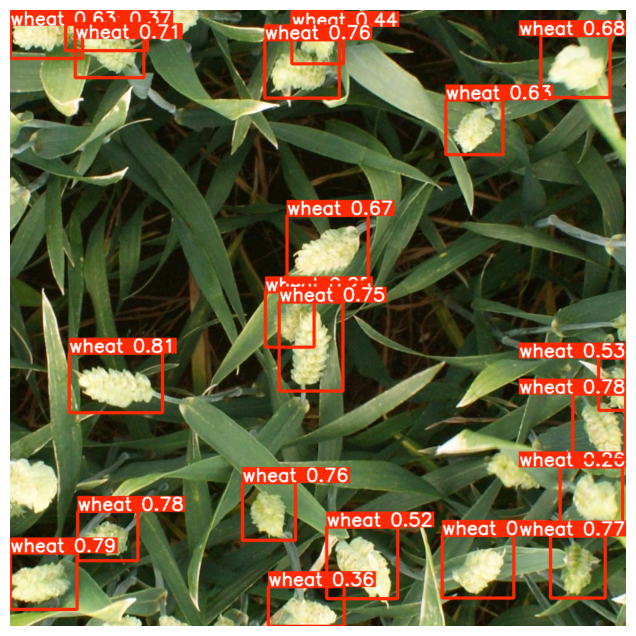

In [ ]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread("/kaggle/input/global-wheat-detection/test/2fd875eaa.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

res = model(img)[0]
annotated = res.plot()

plt.figure(figsize=(8,8))
plt.imshow(annotated)
plt.axis('off')
